In [1]:
import torch 
import glob
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from data_loader import EnsDataLoader

from model import both_structs

In [2]:
testsplit=glob.glob('data/test_data/*/')

In [3]:
%%time
test_data=EnsDataLoader(testsplit,100)

CPU times: user 2min 10s, sys: 1.26 s, total: 2min 11s
Wall time: 2min 11s


In [4]:
model = both_structs(4)
model.load_state_dict(torch.load('training_outputs/original_trained_model/trained_model.pt', weights_only=True))
model.eval()

both_structs(
  (single_gat): my_gat(
    (gat1): GATv2Conv(4, 20, heads=8)
    (gat2): GATv2Conv(160, 40, heads=1)
    (linear1): Linear(in_features=40, out_features=10, bias=True)
  )
  (linear1): Linear(in_features=40, out_features=20, bias=True)
  (linear2): Linear(in_features=20, out_features=30, bias=True)
  (linear3): Linear(in_features=30, out_features=1, bias=True)
)

In [5]:
eval_out = model(test_data.dataset1,test_data.dataset2)

In [7]:
def accuracy(pred_y, y, w=0.2):
    """Calculate accuracy."""
    c=0
    for i in range(0,len(y)):
        if y[i]-0.2 < pred_y[i] < y[i]+0.2:
            c+=1
    return c/ len(y)

In [8]:
accuracy(eval_out.squeeze().tolist(),test_data.labels.tolist())*100

31.65959453088166

In [14]:
MSE = np.square(np.subtract(eval_out.squeeze().tolist(),test_data.labels.tolist())).mean()
print(MSE)

0.21948635326504728


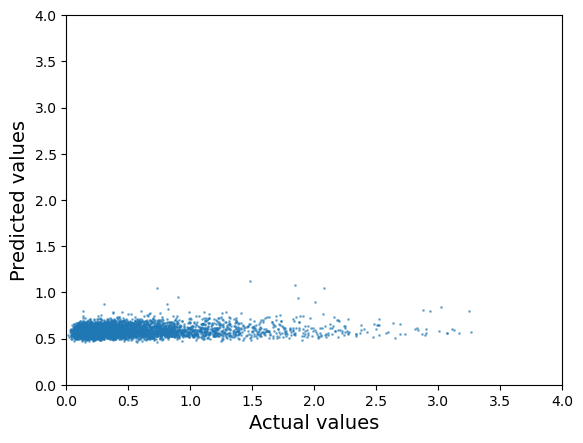

In [16]:
plt.scatter(test_data.labels.tolist(),eval_out.squeeze().tolist(),alpha=0.5,s=1)
plt.xlim(0,4)
plt.ylim(0,4)
plt.xlabel('Actual values',size=14)
plt.ylabel('Predicted values',size=14)

#plt.savefig('figures/test_actual_v_pred.jpeg', dpi=500)